In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Use the standalone Keras installation to avoid TensorFlow protobuf issues
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from pathlib import Path

np.random.seed(42)



2026-05-08 09:01:41.582860: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778230901.595784      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778230901.599733      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-08 09:01:41.615029: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
BASE_PATH = Path("/kaggle/input/leaf-classification")
if not BASE_PATH.exists():
    BASE_PATH = Path("../input/leaf-classification")
train_path = BASE_PATH / "train.csv"
test_path = BASE_PATH / "test.csv"



In [3]:
data = pd.read_csv(train_path)
parent_data = data.copy()  # keep a copy for later column reference
ID = data.pop("id")  # drop id column (kept only for reference)



In [4]:
le = LabelEncoder()
y_raw = data.pop("species")
y_enc = le.fit_transform(y_raw)
print("Encoded label shape:", y_enc.shape)



Encoded label shape: (891,)


In [5]:
scaler = StandardScaler().fit(data.values)
X = scaler.transform(data.values)
print("Feature matrix shape:", X.shape)



Feature matrix shape: (891, 192)


In [6]:
y_cat = to_categorical(y_enc)
print("One‑hot label shape:", y_cat.shape)



One‑hot label shape: (891, 99)


In [7]:
model = Sequential()
model.add(Dense(1024, input_dim=192))
model.add(Dropout(0.2))
model.add(Activation("relu"))
model.add(Dense(512))
model.add(Dropout(0.3))
model.add(Activation("relu"))
model.add(Dense(99))  # 99 leaf species
model.add(Activation("softmax"))



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-08 09:01:47.419044: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778230907.419497      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:85:00.0, compute capability: 8.6


In [8]:
model.compile(loss="categorical_crossentropy", optimizer="adam")
early_stop = EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True, verbose=1
)

history = model.fit(
    X,
    y_cat,
    batch_size=128,
    epochs=200,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)



Epoch 1/200


I0000 00:00:1778230908.498587     112 service.cc:148] XLA service 0x7f78ac009a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778230908.498614     112 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-08 09:01:48.514824: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778230908.590014     112 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-05-08 09:01:49.829673: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_764_0', 1460 bytes spill stores, 1988 bytes spill loads

2026-05-08 09:01:50.012773: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_836', 112 bytes s

1/7 ━━━━━━━━━━━━━━━━━━━━ 1:02 10s/step - loss: 4.8303

I0000 00:00:1778230918.435037     112 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-05-08 09:01:59.162674: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_764', 220 bytes spill stores, 220 bytes spill loads

2026-05-08 09:01:59.417093: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_764_0', 1128 bytes spill stores, 1376 bytes spill loads

2026-05-08 09:01:59.759360: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_764', 8 bytes spill stores, 8 bytes spill loads

2026-05-08 09:01:59.941540: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spille

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 4.4417   

2026-05-08 09:02:08.702703: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 4 bytes spill stores, 4 bytes spill loads

2026-05-08 09:02:09.023833: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 236 bytes spill stores, 236 bytes spill loads

2026-05-08 09:02:09.098244: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23_0', 756 bytes spill stores, 444 bytes spill loads

2026-05-08 09:02:09.223024: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 12 bytes spill stores, 12 bytes spill loads

2026-05-08 09:02:09.536214: I external/local_xla/xla/stream_exec

7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - loss: 4.4024 - val_loss: 2.9565
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.3989 - val_loss: 1.4554
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9973 - val_loss: 0.5912
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4692 - val_loss: 0.2564
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2269 - val_loss: 0.1775
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1568 - val_loss: 0.1292
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0853 - val_loss: 0.0940
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0659 - val_loss: 0.0561
Epoch 9/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0618 - val_loss: 0.0610
Epoch 10/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0463 - val_loss: 0.0782
Epoch 11/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0361 - val_loss: 0.0525
Epoch 12/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0372 - val_loss: 0.0704
Epoch 13/200


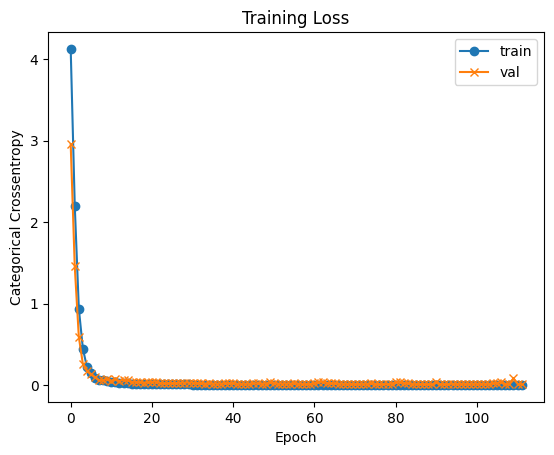

In [9]:
plt.plot(history.history["loss"], "o-", label="train")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], "x-", label="val")
plt.xlabel("Epoch")
plt.ylabel("Categorical Crossentropy")
plt.title("Training Loss")
plt.legend()
plt.show()



In [10]:
test_df = pd.read_csv(test_path)
test_ids = test_df.pop("id")  # keep ids for submission



In [11]:
test_X = scaler.transform(test_df.values)



In [12]:
y_pred = model.predict(test_X)  # shape (num_test, 99)



2026-05-08 09:02:18.111566: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16_0', 88 bytes spill stores, 120 bytes spill loads

2026-05-08 09:02:18.400730: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 220 bytes spill stores, 220 bytes spill loads

2026-05-08 09:02:19.681439: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 136 bytes spill stores, 136 bytes spill loads



1/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step

2026-05-08 09:02:20.413153: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 220 bytes spill stores, 220 bytes spill loads

2026-05-08 09:02:20.983070: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 8 bytes spill stores, 8 bytes spill loads

2026-05-08 09:02:21.116838: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 4 bytes spill stores, 4 bytes spill loads



4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 738ms/step


In [13]:
species_cols = list(le.classes_)  # order matches model outputs
pred_df = pd.DataFrame(y_pred, columns=species_cols)
pred_df.insert(0, "id", test_ids.values)  # add id column as first column
pred_df.to_csv("predictions.csv", index=False)
print("Submission file 'predictions.csv' written with shape:", pred_df.shape)

Submission file 'predictions.csv' written with shape: (99, 100)
